In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# ==========================================================
# LOAD DATASET
# ==========================================================

# Read CSV file from Google Drive
file_path = "/content/drive/MyDrive/Colab Notebooks/Models Data/house_prices_practice.csv"
df = pd.read_csv(file_path)

In [7]:
print(df.head())

   Id  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt  FullBath  \
0   1            7       1560           0         1658       1969         2   
1   2            4       2827           2         1319       2012         3   
2   3            8       3920           0          841       2010         1   
3   4            5       3044           0         1058       1998         0   
4   5            7        801           1         2428       2020         0   

   BedroomAbvGr  LotArea  SalePrice  
0             1     8059     177106  
1             4    13530     301044  
2             4     9010     360609  
3             4    13207     240556  
4             1     9117     193656  


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Id            299 non-null    int64
 1   OverallQual   299 non-null    int64
 2   GrLivArea     299 non-null    int64
 3   GarageCars    299 non-null    int64
 4   TotalBsmtSF   299 non-null    int64
 5   YearBuilt     299 non-null    int64
 6   FullBath      299 non-null    int64
 7   BedroomAbvGr  299 non-null    int64
 8   LotArea       299 non-null    int64
 9   SalePrice     299 non-null    int64
dtypes: int64(10)
memory usage: 23.5 KB
None


In [10]:
print(df.describe())

               Id  OverallQual    GrLivArea  GarageCars  TotalBsmtSF  \
count  299.000000   299.000000   299.000000  299.000000   299.000000   
mean   150.000000     5.314381  2309.528428    1.334448  1470.404682   
std     86.458082     2.869913  1043.647805    1.109077   672.882740   
min      1.000000     1.000000   504.000000    0.000000   303.000000   
25%     75.500000     3.000000  1389.500000    0.000000   903.000000   
50%    150.000000     5.000000  2273.000000    1.000000  1502.000000   
75%    224.500000     8.000000  3307.000000    2.000000  2131.000000   
max    299.000000    10.000000  3998.000000    3.000000  2492.000000   

         YearBuilt    FullBath  BedroomAbvGr       LotArea      SalePrice  
count   299.000000  299.000000    299.000000    299.000000     299.000000  
mean   1986.257525    1.521739      2.933110   8950.779264  252421.033445  
std      21.350477    1.133103      1.454756   3745.838645   75073.673370  
min    1950.000000    0.000000      1.000000   

In [13]:
print(df.columns)

Index(['Id', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
       'YearBuilt', 'FullBath', 'BedroomAbvGr', 'LotArea', 'SalePrice'],
      dtype='object')


In [14]:
print(df.isnull().sum())

Id              0
OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
LotArea         0
SalePrice       0
dtype: int64


In [15]:
X = df[
    [
        "OverallQual",
        "GrLivArea",
        "GarageCars",
        "TotalBsmtSF",
        "YearBuilt",
        "FullBath",
        "BedroomAbvGr",
        "LotArea"
    ]
]

In [16]:
y = df["SalePrice"]

In [18]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [19]:
model = LinearRegression()

In [20]:
model.fit(X_train,y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)
print(y_pred)

[209887.93437683 192303.94542774 291753.84397199 222396.59635491
 375347.6369643  270802.5755138  235066.63221358 205745.84877144
 203323.62909771 162033.05015899 179701.31037583 264053.978638
 206941.56216914 278121.29919024 274509.02464365 291123.54480937
 288239.01250087 231298.0474138  318606.10340087 271502.03922846
 347774.86976099 311432.91844285 325854.3120797  235894.17315534
 382465.51391977 171936.34538302 151707.69581869 255249.04535999
 120294.64536951 216793.88015449 402279.12521943 112493.72568795
 123470.82237192 209677.7382087  172387.03999828 342103.52161168
 167987.21080073 176718.76870977 221109.5310664  333296.45864131
 303665.4207154  176978.59490653 222141.80806699 334768.65662411
 233808.29263247 156839.87960676 193874.3925343  167719.9840174
 278754.20102225 315117.24059957 317753.2739416  168636.09186799
 171334.21226731 274620.35267181 149260.93152187 199298.05617299
 289058.40545878 140617.60809804 176308.09238382 241454.01304982
 144101.88710686 222563.1634

In [23]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})
print(comparison.head(10))

     Actual      Predicted
281  225589  209887.934377
265  181535  192303.945428
164  290763  291753.843972
9    211664  222396.596355
77   353246  375347.636964
278  265591  270802.575514
93   215533  235066.632214
109  209025  205745.848771
5    213952  203323.629098
173  153184  162033.050159


In [24]:
mae = mean_absolute_error(y_test,y_pred)
print(mae)

10420.98747509377


In [25]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

150340889.77334502


In [26]:
r2= r2_score(y_test,y_pred)
print(r2)

0.9755200417731869


In [27]:
new_house=[[
    9,1667,0,988,1958,2,1,14553
]]
prediction = model.predict(new_house)
print(prediction)

[195751.4239909]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


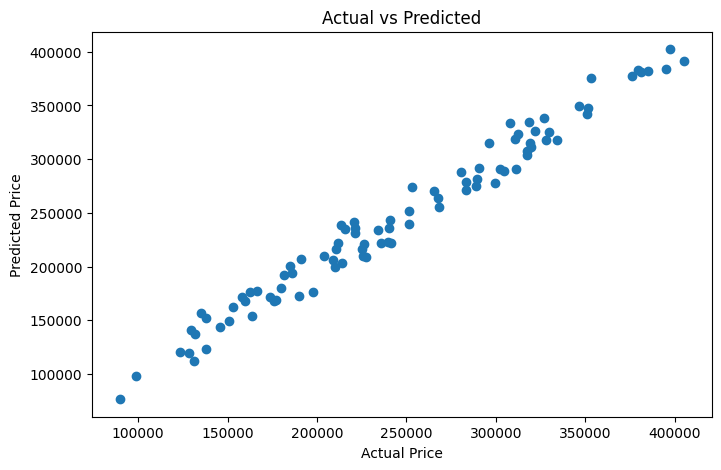

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()